numpy
pandas
scikit-learn
matplotlib
seaborn

In [96]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


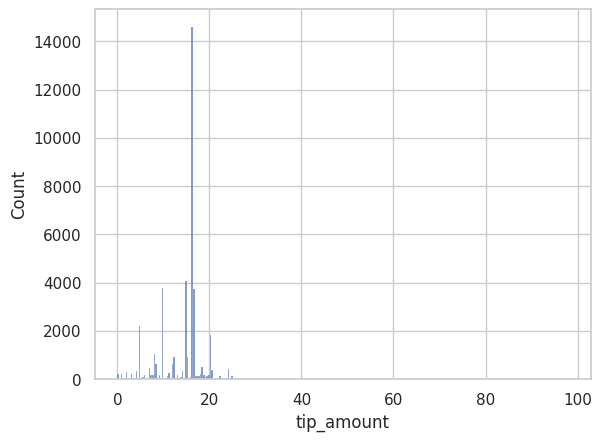

In [97]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)
# TODO: Inspect it
taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
sns.histplot(taxi['tip_amount'])
plt.show()
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

In [98]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[(taxi['trip_distance']>= 0) & (taxi['fare_amount']>=0)]
taxi = taxi[taxi['tip_amount']>=0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare-per-mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_columns = ['VendorID','RatecodeID','payment_type','store_and_fwd_flag']
taxi = pd.get_dummies(taxi, columns = categorical_columns, drop_first = True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler
X = taxi.drop('tip_amount',axis=1)
Y = taxi['tip_amount']
x = pd.get_dummies(X, drop_first=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

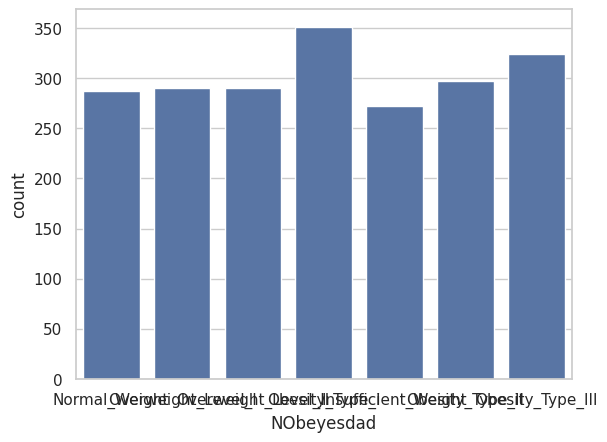

In [99]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print(obesity['NObeyesdad'].value_counts)
sns.countplot(data = obesity, x = 'NObeyesdad' )
plt.show()

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
order_map = {'no': 0,'Sometimes': 1,'Frequently': 2,  'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(order_map)
obesity['CALC'] = obesity['CALC'].map(order_map)

categorical_cols = []

if 'Gender' in obesity.columns:
    categorical_cols.append('Gender')

if 'MTRANS' in obesity.columns:
    categorical_cols.append('MTRANS')

if len(categorical_cols) > 0:
    obesity = pd.get_dummies(obesity,columns=categorical_cols,drop_first=True,dtype=int)

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)
obesity['NObeyesdad'] = obesity['NObeyesdad'].astype('category').cat.codes

X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.25,stratify=y_train,random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [101]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#  Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=RANDOM_STATE)

X_train, X_val, y_train,y_val = train_test_split(X_train,y_train,test_size=0.25, stratify=y_train,random_state=RANDOM_STATE)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
mean = X_train.mean()
std = X_train.std()
X_train_scaled = (X_train - mean) / std
X_val_scaled = (X_val - mean) / std
X_test_scaled = (X_test - mean) / std

Train Accuracy: 0.9241706161137441
Train Macro-f1: 0.9216924878748501
Validation Accuracy: 0.8791469194312796
Validation Macro-f1: 0.8728259358673748
Test Accuracy: 0.8936170212765957
Test Macro-f1: 0.8895425359817121
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       0.89      0.72      0.80        58
           2       0.94      0.94      0.94        70
           3       0.95      1.00      0.98        60
           4       1.00      0.98      0.99        65
           5       0.73      0.79      0.76        58
           6       0.81      0.79      0.80        58

    accuracy                           0.89       423
   macro avg       0.89      0.89      0.89       423
weighted avg       0.89      0.89      0.89       423



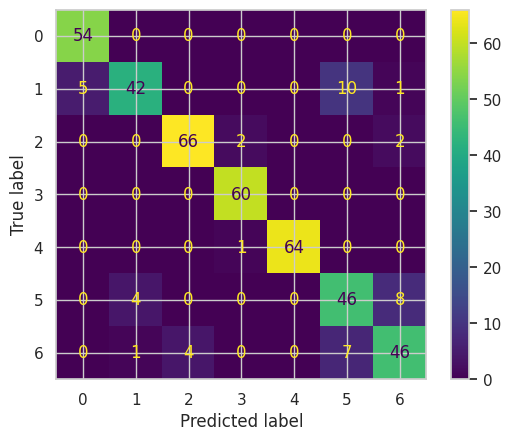

In [102]:
# TODO: Import, initialise, and train a classifier
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
y_train_predict = clf.predict(X_train_scaled)
y_val_predict = clf.predict(X_val_scaled)
y_test_predict = clf.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
from sklearn.metrics import accuracy_score, f1_score, classification_report

print('Train Accuracy:', accuracy_score(y_train, y_train_predict))
print('Train Macro-f1:', f1_score(y_train, y_train_predict, average='macro'))
print('Validation Accuracy:', accuracy_score(y_val, y_val_predict))
print('Validation Macro-f1:', f1_score(y_val, y_val_predict, average='macro'))
print('Test Accuracy:', accuracy_score(y_test, y_test_predict))
print('Test Macro-f1:', f1_score(y_test, y_test_predict, average='macro'))
print(classification_report(y_test, y_test_predict))

# TODO: Show a confusion matrix for the test set
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_test_predict)

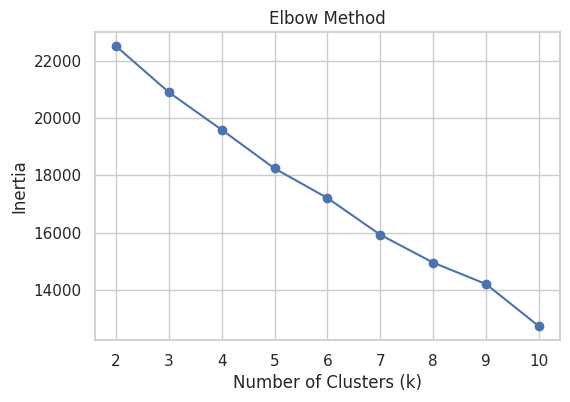

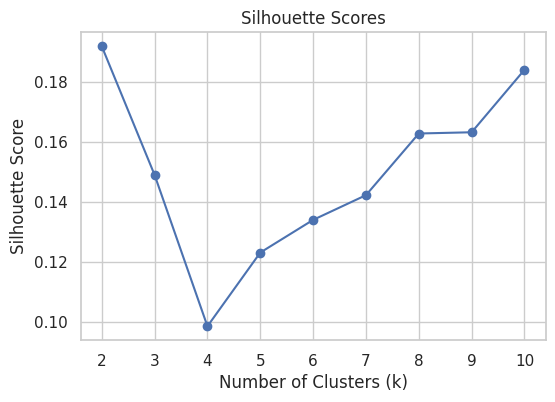

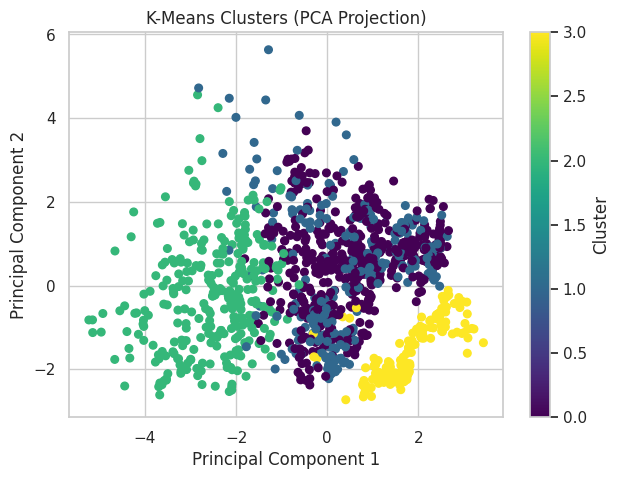

In [104]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_train_scaled

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

# Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Scores
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 4   # Change this based on the elbow/silhouette plots

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=30
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()

In [106]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
cluster_true = pd.crosstab(
    cluster_labels,
    y_train,
    rownames = ['cluster'],
    colnames = ['True Obesity Levl']
)
print(cluster_true)

True Obesity Levl    0    1    2    3    4   5   6
cluster                                           
0                   43   36  140  123    0  95  80
1                    2   27   66   53    0  43  64
2                  118  109    1    1    0  36  28
3                    0    0    4    1  194   0   2
